# Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error
from qiskit.circuit.library import pauli_feature_map
from qiskit_machine_learning.kernels import FidelityStatevectorKernel
from multiprocessing import Process


import os


os.makedirs("../results/experiment_15_oshank", exist_ok=True)

# Loading data

In [88]:
X = pd.read_csv("../dataset/o_shank.csv")[1000:3000]
y = pd.read_csv("../dataset/distances.csv").iloc[:, 1].to_numpy()[1000:3000]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

features = pd.read_csv("../results/data_analysis_oshank/selected_features.csv")["feature"].tolist()
print(features)

['z_value_2', 'z_value_1', 'z_sin_term_2_2', 'z_cos_term_2_2', 'z_sin_term_6_2', 'z_sin_term_2_1', 'z_cos_term_2_1', 'z_cos_term_3_1', 'z_cos_term_1_1', 'z_sin_term_5_2']


# SVR

In [89]:
def run_classical_experiment():
    results = []

    param_grid = {
        "svr__C": [0.1, 1, 5, 10],
        "svr__epsilon": [0.001, 0.01, 0.1, 0.5],
        "svr__gamma": ["scale", 0.01, 0.1, 1.0]
    }

    n_features = [i for i in range(2, 11)]

    for n in n_features:
        print(f"Running experiment for group: Rank Aggregation with {n} features")

        X_train_subset = X_train[features[:n]].to_numpy()
        X_test_subset = X_test[features[:n]].to_numpy()

        pipeline = Pipeline([
            ("scaler", MinMaxScaler()),
            ("svr", SVR(kernel="rbf"))
        ])

        grid = GridSearchCV(
            pipeline,
            param_grid,
            scoring="neg_root_mean_squared_error",
            cv=KFold(n_splits=2, shuffle=True, random_state=42),
            n_jobs=-1
        )

        grid.fit(X_train_subset, y_train)

        best_model = grid.best_estimator_
        y_pred = best_model.predict(X_test_subset)

        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        results.append({
            "MSE": mse,
            "R2": r2,
            "Best C": grid.best_params_["svr__C"],
            "Best epsilon": grid.best_params_["svr__epsilon"],
            "Best gamma": grid.best_params_["svr__gamma"],
            "Features": n
        })

    results_df = pd.DataFrame(results).sort_values("MSE").reset_index(drop=True)
    print(results_df)
    results_df.to_csv("../results/experiment_15_oshank/classical_experiment_results.csv", index=False)

    plot_df = pd.DataFrame(results).sort_values("Features")
    plt.figure(figsize=(10, 6))
    plt.plot(plot_df["Features"], plot_df["MSE"], 'b-o')
    plt.xlabel("Número de Características")
    plt.ylabel("MSE")
    plt.title("MSE por Número de Características")
    plt.xticks(n_features)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Running experiment for group: Rank Aggregation with 2 features
Running experiment for group: Rank Aggregation with 3 features
Running experiment for group: Rank Aggregation with 4 features
Running experiment for group: Rank Aggregation with 5 features
Running experiment for group: Rank Aggregation with 6 features
Running experiment for group: Rank Aggregation with 7 features
Running experiment for group: Rank Aggregation with 8 features
Running experiment for group: Rank Aggregation with 9 features
Running experiment for group: Rank Aggregation with 10 features
        MSE        R2  Best C  Best epsilon Best gamma  Features
0  0.007493  0.914371      10          0.01      scale        10
1  0.008243  0.905796      10          0.01        1.0         9
2  0.016635  0.809891      10          0.01      scale         8
3  0.020272  0.768328      10          0.10      scale         5
4  0.020928  0.760832      10          0.01      scale         6
5  0.021657  0.752503      10          0.0

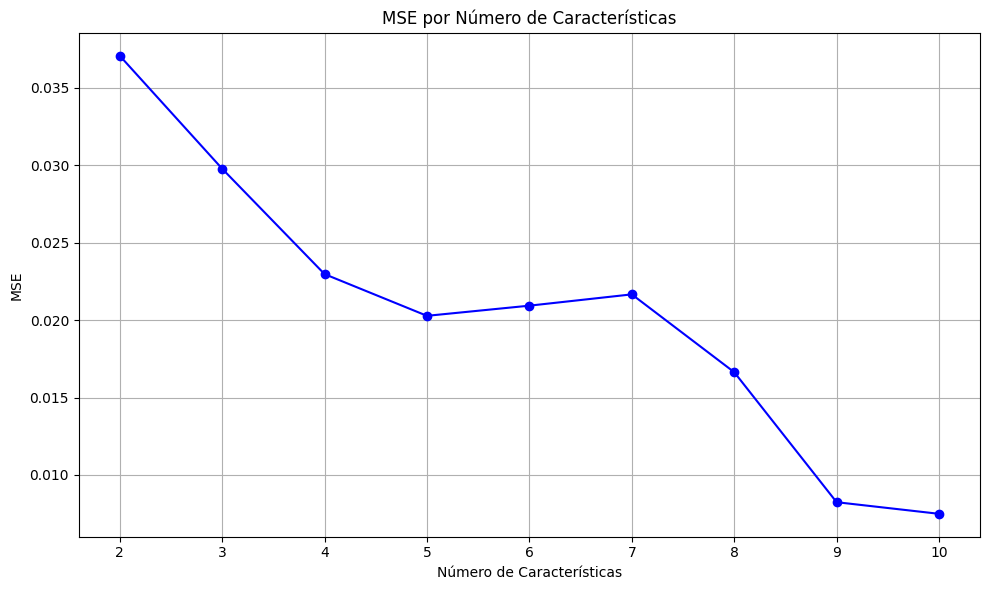

In [90]:
run_classical_experiment()

## Pauli Feature Map Custom Feature Map

In [91]:
def riemann_advanced_data_map(x):
    x = np.asarray(x)

    x_safe = x + 1e-8

    theta_like = np.sum(x_safe * np.log(x_safe))
    val = np.cos(theta_like)

    for i in range(len(x) - 1):
        val += 0.3 * np.cos(x[i] - x[i+1])
        val += 0.3 * np.sin(x[i] * x[i+1])

    return val


def preproc_rbf_s1(X: np.ndarray) -> np.ndarray:
    return np.exp(-(X ** 2) / 2.0)


def full_pauli_labels(n_qubits: int):
    from itertools import product
    alphabet = ["I", "X", "Y", "Z"]
    return ["".join(p) for p in product(alphabet, repeat=n_qubits)]


def run_quantum_experiment_pauli_feature_map():
    results = []
    n_features = [2, 3, 4, 5, 6, 7, 8, 9, 10]

    param_grid = {
        "C": [0.1, 1, 5, 10],
        "epsilon": [0.001, 0.01, 0.1, 0.5]
    }

    for n in n_features:
        print(f"Running quantum experiment with {n} features using Pauli feature map")

        X_train_subset = X_train[features[:n]].to_numpy()
        X_test_subset = X_test[features[:n]].to_numpy()

        scaler_X = MinMaxScaler(feature_range=(0, np.pi))
        X_train_scaled = scaler_X.fit_transform(X_train_subset)
        X_test_scaled = scaler_X.transform(X_test_subset)

        X_train_scaled = preproc_rbf_s1(X_train_scaled)
        X_test_scaled  = preproc_rbf_s1(X_test_scaled)

        kernel = FidelityStatevectorKernel(feature_map=pauli_feature_map(
            feature_dimension=n,
            paulis=["Y", "YY"],
            entanglement="full",
            reps=1,
            data_map_func=riemann_advanced_data_map,
        ))

        kernel_matrix = kernel.evaluate(X_train_scaled)
        kernel_matrix_test = kernel.evaluate(X_test_scaled, X_train_scaled)

        grid = GridSearchCV(
            SVR(kernel="precomputed"),
            param_grid,
            scoring="neg_mean_squared_error",
            cv=KFold(n_splits=2, shuffle=True, random_state=42),
            n_jobs=-1
        )

        grid.fit(kernel_matrix, y_train)

        best_model = grid.best_estimator_
        y_pred = best_model.predict(kernel_matrix_test)

        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        print(f"Results for {n} features: MSE = {mse:.4f}, R2 = {r2:.4f}")

        results.append({
            "N Features": n,
            "MSE": mse,
            "R2": r2,
            "Best C": grid.best_params_["C"],
            "Best epsilon": grid.best_params_["epsilon"],
        })

    results_df = pd.DataFrame(results).sort_values("MSE").reset_index(drop=True)
    print(results_df)
    results_df.to_csv("../results/experiment_15_oshank/quantum_pauli_results.csv", index=False)

    plot_df = pd.DataFrame(results).sort_values("N Features")
    plt.figure(figsize=(10, 6))
    plt.plot(plot_df["N Features"], plot_df["MSE"], 'r-o')
    plt.xlabel("Número de Características")
    plt.ylabel("MSE")
    plt.title("MSE por Número de Características (Quantum Pauli Feature Map)")
    plt.xticks(n_features)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return results_df

## Pauli Feature Map Default

In [92]:
def preproc_rbf_s1(X: np.ndarray) -> np.ndarray:
    return np.exp(-(X ** 2) / 2.0)


def run_quantum_experiment_pauli_feature_map_default():
    results = []
    n_features = [2, 3, 4, 5, 6, 7, 8, 9, 10]

    param_grid = {
        "C": [0.1, 1, 5, 10],
        "epsilon": [0.001, 0.01, 0.1, 0.5]
    }

    for n in n_features:
        print(f"Running quantum experiment with {n} features using Pauli feature map")

        X_train_subset = X_train[features[:n]].to_numpy()
        X_test_subset = X_test[features[:n]].to_numpy()

        scaler_X = MinMaxScaler(feature_range=(0, np.pi))
        X_train_scaled = scaler_X.fit_transform(X_train_subset)
        X_test_scaled = scaler_X.transform(X_test_subset)

        X_train_scaled = preproc_rbf_s1(X_train_scaled)
        X_test_scaled  = preproc_rbf_s1(X_test_scaled)

        kernel = FidelityStatevectorKernel(feature_map=pauli_feature_map(
            feature_dimension=n,
            paulis=["Y", "YY"],
            entanglement="full",
            reps=1
        ))

        kernel_matrix = kernel.evaluate(X_train_scaled)
        kernel_matrix_test = kernel.evaluate(X_test_scaled, X_train_scaled)

        grid = GridSearchCV(
            SVR(kernel="precomputed"),
            param_grid,
            scoring="neg_mean_squared_error",
            cv=KFold(n_splits=2, shuffle=True, random_state=42),
            n_jobs=-1
        )

        grid.fit(kernel_matrix, y_train)

        best_model = grid.best_estimator_
        y_pred = best_model.predict(kernel_matrix_test)

        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        print(f"Results for {n} features: MSE = {mse:.4f}, R2 = {r2:.4f}")

        results.append({
            "N Features": n,
            "MSE": mse,
            "R2": r2,
            "Best C": grid.best_params_["C"],
            "Best epsilon": grid.best_params_["epsilon"],
        })

    results_df = pd.DataFrame(results).sort_values("MSE").reset_index(drop=True)
    print(results_df)
    results_df.to_csv("../results/experiment_15_oshank/quantum_pauli_results_default.csv", index=False)

    plot_df = pd.DataFrame(results).sort_values("N Features")
    plt.figure(figsize=(10, 6))
    plt.plot(plot_df["N Features"], plot_df["MSE"], 'r-o')
    plt.xlabel("Número de Características")
    plt.ylabel("MSE")
    plt.title("MSE por Número de Características (Quantum Pauli Feature Map Default)")
    plt.xticks(n_features)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return results_df

## Fourier Feature Map

In [93]:
def fourier_feature_map(x, wires):
    for i in range(len(wires)):
        qml.RX(x[i], wires=wires[i])
        qml.RZ(x[i], wires=wires[i])

    for i in range(len(wires)-1):
        qml.CNOT(wires=[wires[i], wires[i+1]])

    for i in range(len(wires)):
        qml.RZ(np.sin(x[i]) + np.cos(2*x[i]), wires=wires[i])


def make_fourier_kernel(n_qubits):
    dev = qml.device("lightning.qubit", wires=n_qubits)

    @qml.qnode(dev)
    def kernel_fn(x1, x2):
        wires = range(n_qubits)

        fourier_feature_map(x1, wires=wires)
        qml.adjoint(fourier_feature_map)(x2, wires=wires)

        return qml.expval(qml.Projector([0] * n_qubits, wires=wires))

    return kernel_fn


def run_fourier_experiment():
    results = []
    n_qubits = list(range(2, 11))
    kernels = {f"{n}_Fourier": (make_fourier_kernel(n), n) for n in n_qubits}

    param_grid = {
        "svr__C": [1, 5],
        "svr__epsilon": [0.01, 0.1]
    }

    for name, (kernel, n) in kernels.items():
        print(f"Running kernel {name}")

        kernel_mat = lambda A, B, kf=kernel: qml.kernels.kernel_matrix(A, B, kf)

        pipeline = Pipeline([
            ("scaler", MinMaxScaler(feature_range=(0, np.pi))),
            ("svr", SVR(kernel=kernel_mat))
        ])

        X_train_subset = X_train[features[:n]].to_numpy()
        X_test_subset = X_test[features[:n]].to_numpy()

        grid = GridSearchCV(
            pipeline,
            param_grid,
            scoring="neg_mean_squared_error",
            cv=KFold(n_splits=2),
        )

        grid.fit(X_train_subset, y_train)

        best_model = grid.best_estimator_
        y_pred = best_model.predict(X_test_subset)
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        print(f"Kernel: {name}, MSE: {mse:.4f}, R^2: {r2:.4f}")
        results.append({
            "kernel": name,
            "n_qubits": n,
            "mse": mse,
            "r2": r2,
            "best_c": grid.best_params_["svr__C"],
            "best_epsilon": grid.best_params_["svr__epsilon"]
        })

    results_df = pd.DataFrame(results)
    print(results_df)
    results_df\
        .sort_values("mse")\
        .to_csv("../results/experiment_15_oshank/fourier_experiment_results.csv", index=False)

    plot_df = pd.DataFrame(results).sort_values("n_qubits")
    plt.figure(figsize=(10, 6))
    plt.plot(plot_df["n_qubits"], plot_df["mse"], 'm-o')
    plt.xlabel("Número de Qubits")
    plt.ylabel("MSE")
    plt.title("MSE por Número de Qubits (Fourier Kernel)")
    plt.xticks(n_qubits)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## Angle Entangled Feature Map

In [94]:
def feature_map(x, wires, rotation_first="X", rotation_second="Y"):
    qml.AngleEmbedding(x, wires=wires, rotation=rotation_first)
    qml.BasicEntanglerLayers(
        weights=np.zeros((1, len(wires))),
        wires=wires,
        rotation=qml.RZ
    )
    qml.AngleEmbedding(x, wires=wires, rotation=rotation_second)


def make_simple_kernel(n_qubits, rotation_first="X", rotation_second="Y"):
    dev = qml.device("lightning.qubit", wires=n_qubits)

    @qml.qnode(dev)
    def kernel_fn(x1, x2):
        wires = range(n_qubits)
        feature_map(x1, wires=wires, rotation_first=rotation_first, rotation_second=rotation_second)
        qml.adjoint(feature_map)(x2, wires=wires, rotation_first=rotation_first, rotation_second=rotation_second)
        return qml.expval(qml.Projector([0] * n_qubits, wires=wires))

    return kernel_fn


def run_simple_experiment():
    results = []

    param_grid = {
        "svr__C": [1, 5],
        "svr__epsilon": [0.01, 0.1]
    }

    n_qubits = list(range(2, 11))
    kernels = {f"{n}_XY": (make_simple_kernel(n, rotation_first="X", rotation_second="Y"), n) for n in n_qubits}

    for name, (kernel, n) in kernels.items():
        print(f"Running kernel {name}")

        kernel_mat = lambda A, B, kf=kernel: qml.kernels.kernel_matrix(A, B, kf)

        pipeline = Pipeline([
            ("scaler", MinMaxScaler(feature_range=(0, np.pi))),
            ("svr", SVR(kernel=kernel_mat))
        ])

        X_train_subset = X_train[features[:n]].to_numpy()
        X_test_subset = X_test[features[:n]].to_numpy()

        grid = GridSearchCV(
            pipeline,
            param_grid,
            scoring="neg_mean_squared_error",
            cv=KFold(n_splits=2, shuffle=True, random_state=42),
        )

        grid.fit(X_train_subset, y_train)

        best_model = grid.best_estimator_
        y_pred = best_model.predict(X_test_subset)
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        print(f"Kernel: {name}, MSE: {mse:.4f}, R^2: {r2:.4f}")
        results.append({
            "kernel": name,
            "n_qubits": n,
            "MSE": mse,
            "R2": r2,
            "best_c": grid.best_params_["svr__C"],
            "best_epsilon": grid.best_params_["svr__epsilon"]
        })

    results_df = pd.DataFrame(results).sort_values("MSE").reset_index(drop=True)
    print(results_df)
    results_df.to_csv("../results/experiment_15_oshank/simple_experiment_results.csv", index=False)

    plot_df = pd.DataFrame(results).sort_values("n_qubits")
    plt.figure(figsize=(10, 6))
    plt.plot(plot_df["n_qubits"], plot_df["MSE"], 'g-o')
    plt.xlabel("Número de Qubits")
    plt.ylabel("MSE")
    plt.title("MSE por Número de Qubits (Simple Quantum Kernel)")
    plt.xticks(n_qubits)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Running quantum experiment with 2 features using Pauli feature map
Running quantum experiment with 2 features using Pauli feature map
Results for 2 features: MSE = 0.0438, R2 = 0.4996
Running quantum experiment with 3 features using Pauli feature map
Results for 2 features: MSE = 0.0428, R2 = 0.5108
Running quantum experiment with 3 features using Pauli feature map
Results for 3 features: MSE = 0.0305, R2 = 0.6518
Running quantum experiment with 4 features using Pauli feature map
Results for 3 features: MSE = 0.0380, R2 = 0.5656
Running quantum experiment with 4 features using Pauli feature map
Results for 4 features: MSE = 0.0239, R2 = 0.7264
Running quantum experiment with 5 features using Pauli feature map
Results for 4 features: MSE = 0.0334, R2 = 0.6188
Running quantum experiment with 5 features using Pauli feature map
Results for 5 features: MSE = 0.0249, R2 = 0.7156
Running quantum experiment with 6 features using Pauli feature map
Results for 5 features: MSE = 0.0281, R2 = 0.67

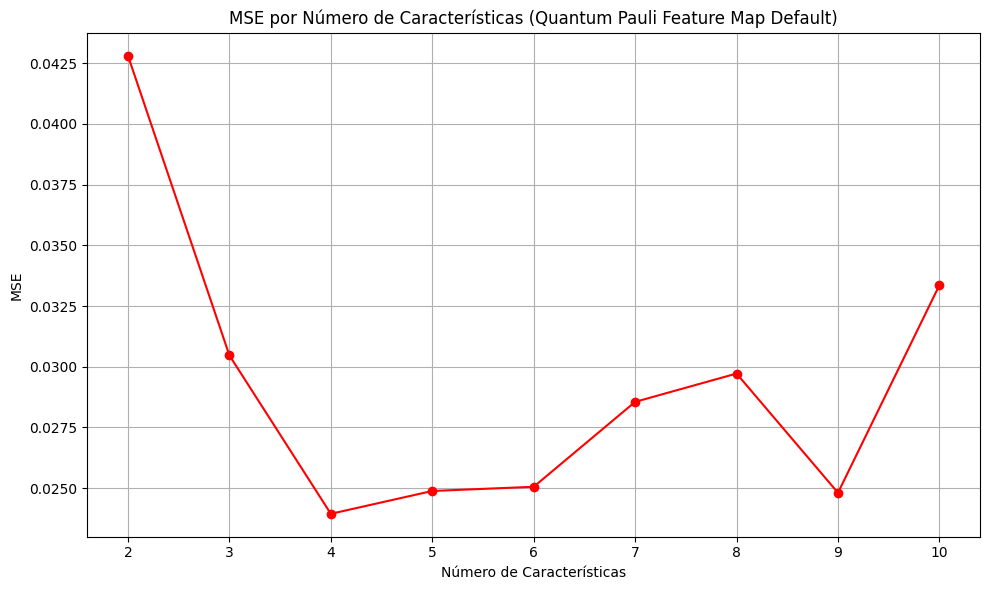

Results for 10 features: MSE = 0.0090, R2 = 0.8972
   N Features       MSE        R2  Best C  Best epsilon
0           9  0.008756  0.899936      10          0.01
1          10  0.008992  0.897244      10          0.01
2           8  0.018191  0.792113      10          0.10
3           7  0.020950  0.760577      10          0.10
4           6  0.020972  0.760335      10          0.01
5           5  0.028108  0.678775      10          0.10
6           4  0.033355  0.618821      10          0.01
7           3  0.038016  0.565554      10          0.01
8           2  0.043788  0.499589      10          0.01


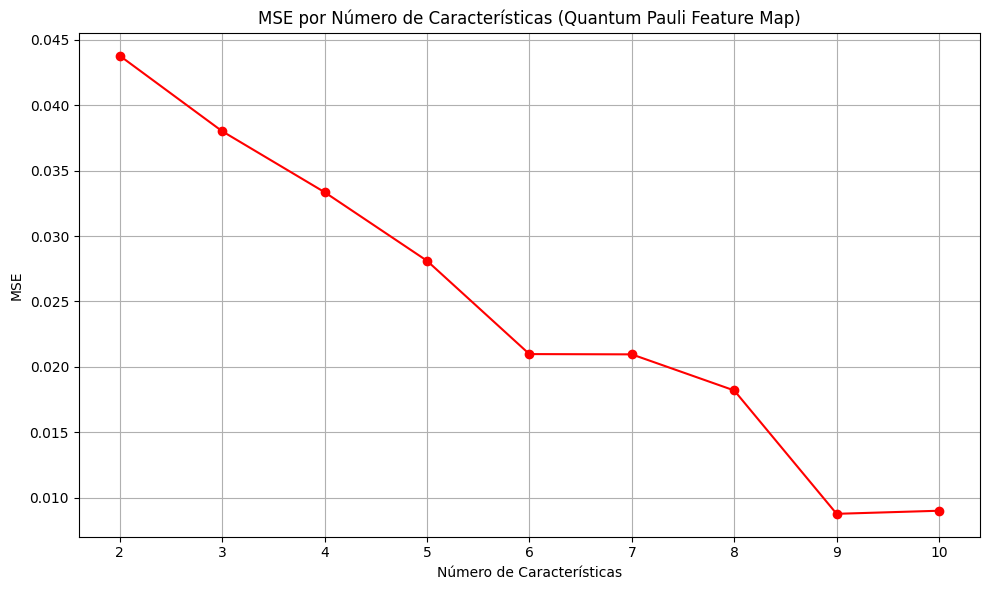

In [97]:
p_pauli_feature_map = Process(target=run_quantum_experiment_pauli_feature_map)
p_pauli_feature_map_default = Process(target=run_quantum_experiment_pauli_feature_map_default)

p_pauli_feature_map.start()
p_pauli_feature_map_default.start()
p_pauli_feature_map.join()
p_pauli_feature_map_default.join()

In [ ]:
run_simple_experiment()

Running kernel 2_XY


In [98]:
p_simple = Process(target=run_simple_experiment)
p_fourier = Process(target=run_fourier_experiment)

p_simple.start()
p_fourier.start()
p_simple.join()
p_fourier.join()

Running kernel 2_XY
Running kernel 2_Fourier


Process Process-170:
Process Process-171:
Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/lib64/python3.13/multiprocessing/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^


KeyboardInterrupt: 

  File "/usr/lib64/python3.13/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib64/python3.13/multiprocessing/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^
  File "/tmp/ipykernel_416704/2775115257.py", line 58, in run_fourier_experiment
    grid.fit(X_train_subset, y_train)
    ~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib64/python3.13/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_416704/736081099.py", line 55, in run_simple_experiment
    grid.fit(X_train_subset, y_train)
    ~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/gabriel/Documents/ic_qc/rgpe/venv/lib64/python3.13/site-packages/sklearn/base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/gabriel/Documents/ic_qc/rgpe/venv/lib64/python3.13/site-

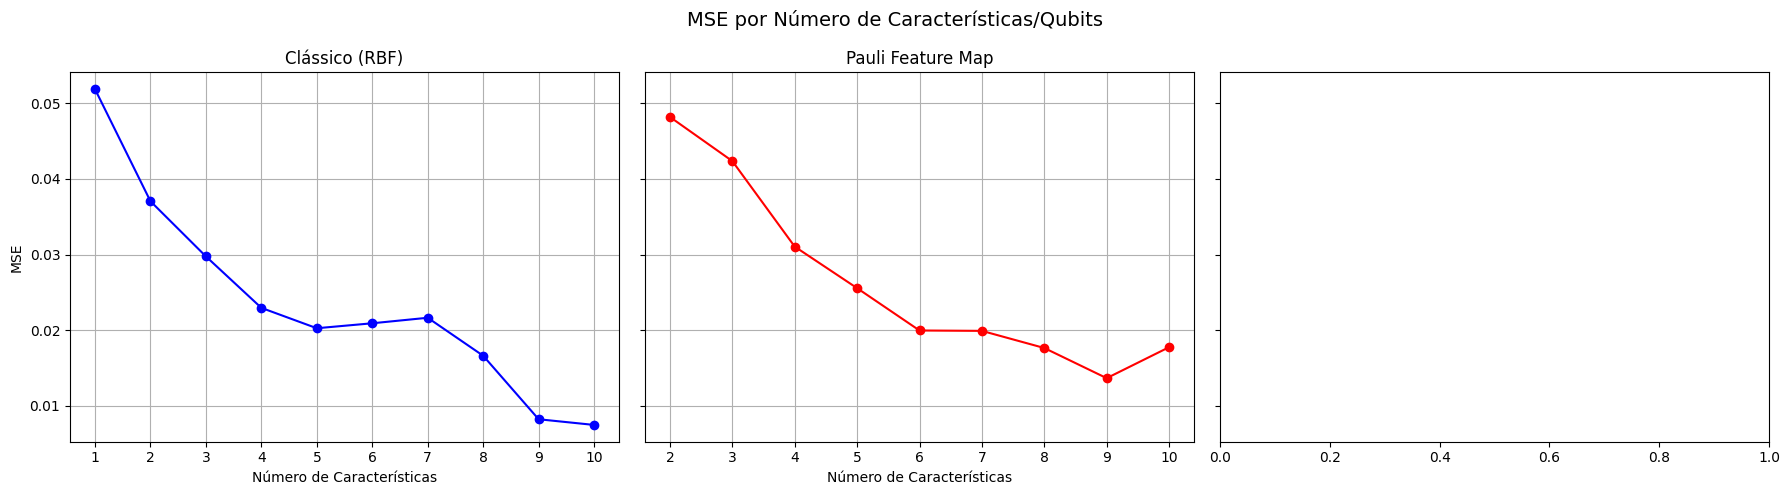

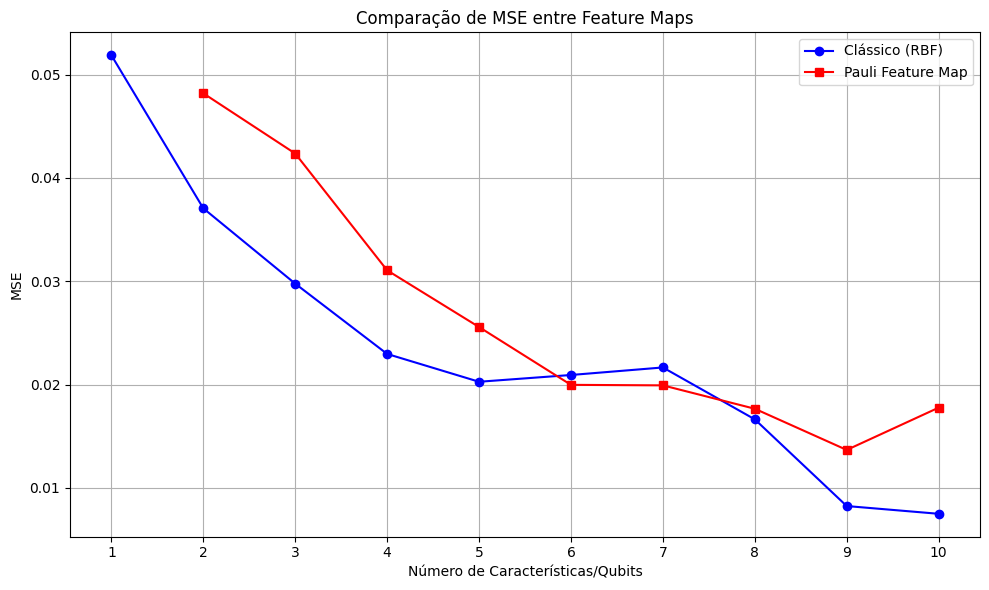

In [ ]:
def plot_combined_results():
    classical_df = pd.read_csv("../results/experiment_15_oshank/classical_experiment_results.csv")
    pauli_df     = pd.read_csv("../results/experiment_15_oshank/quantum_pauli_results.csv")
    pauli_default_df = pd.read_csv("../results/experiment_15_oshank/quantum_pauli_results_default.csv")
    simple_df    = pd.read_csv("../results/experiment_15_oshank/simple_experiment_results.csv")
    fourier_df   = pd.read_csv("../results/experiment_15_oshank/fourier_experiment_results.csv")

    classical_df = classical_df.sort_values("Features")
    pauli_df = pauli_df.sort_values("n_qubits")
    pauli_default_df = pauli_default_df.sort_values("n_qubits")
    simple_df = simple_df.sort_values("n_qubits")
    fourier_df = fourier_df.sort_values("n_qubits")

    fig, axes = plt.subplots(1, 5, figsize=(24, 5), sharey=True)

    n_qubits = list(range(2, 11))

    axes[0].plot(classical_df["Features"], classical_df["MSE"], 'b-o')
    axes[0].set_title("Clássico (RBF)")
    axes[0].set_xlabel("Número de Características")
    axes[0].set_ylabel("MSE")
    axes[0].set_xticks(n_qubits)
    axes[0].grid(True)

    axes[1].plot(pauli_df["n_qubits"], pauli_df["MSE"], 'r-o')
    axes[1].set_title("Pauli Feature Map")
    axes[1].set_xlabel("Número de Características/Qubits")
    axes[1].set_xticks(n_qubits)
    axes[1].grid(True)

    axes[2].plot(pauli_default_df["n_qubits"], pauli_default_df["MSE"], 'c-o')
    axes[2].set_title("Pauli Feature Map (Default)")
    axes[2].set_xlabel("Número de Características/Qubits")
    axes[2].set_xticks(n_qubits)
    axes[2].grid(True)

    axes[3].plot(simple_df["n_qubits"], simple_df["MSE"], 'g-o')
    axes[3].set_title("Angle Encoding")
    axes[3].set_xlabel("Número de Qubits")
    axes[3].set_xticks(n_qubits)
    axes[3].grid(True)

    axes[4].plot(fourier_df["n_qubits"], fourier_df["mse"], 'm-o')
    axes[4].set_title("Fourier Kernel")
    axes[4].set_xlabel("Número de Qubits")
    axes[4].set_xticks(n_qubits)
    axes[4].grid(True)

    fig.suptitle("MSE por Número de Características/Qubits", fontsize=14)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.plot(classical_df["Features"], classical_df["MSE"], 'b-o', label="Clássico (RBF)")
    plt.plot(pauli_df["n_qubits"], pauli_df["MSE"], 'r-s', label="Pauli Feature Map (Custom Data Map)")
    plt.plot(pauli_default_df["n_qubits"], pauli_default_df["MSE"], 'c-s', label="Pauli Feature Map (Default)")
    plt.plot(simple_df["n_qubits"], simple_df["mse"], 'g-^', label="Angle Encoding")
    plt.plot(fourier_df["n_qubits"], fourier_df["mse"], 'm-o', label="Fourier Kernel")

    plt.xlabel("Número de Características/Qubits")
    plt.ylabel("MSE")
    plt.title("Comparação de MSE entre Feature Maps")
    plt.xticks(n_qubits)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


plot_combined_results()